In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime
from scipy.stats import norm

import os

### 0. About std

Оценка дисперсии может быть смещенной и несмещенной. Это важно на малый объемах данных, где разница между оценками будет существенна. На больших объемах данных тип оценка существенного значения не имеет. В курсе применяется смещенная оценка

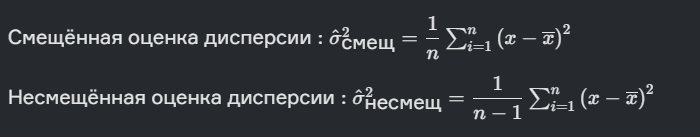

Способы расчета смещенных и несмещзенных оценок дисперсии

In [2]:
values = np.arange(5)

# смещённые оценки дисперсии равны 2.0
var_1 = ((values - values.mean()) ** 2).mean()
var_2 = values.var()
var_3 = pd.Series(values).var(ddof=0)

# несмещённые оценки дисперсии равны 2.5
var_1 = ((values - values.mean()) ** 2).sum() / (len(values) - 1)
var_2 = values.var(ddof=1)
var_3 = pd.Series(values).var()

### Task 1.

Оценить необходимый размер групп
  

Допустим, мы хотим провести эксперимент, в который попадают клиенты, совершившие покупку во время эксперимента.

Метрика — средняя выручка с пользователя за время эксперимента;

Продолжительность — одна неделя;

Уровень значимости — 0.05;

Допустимая вероятность ошибки II рода — 0.1;

Ожидаемый эффект — 20 рублей.

Оцените необходимый размер групп по данным о покупках за неделю с 21 по 28 февраля. Обратим внимание, что в выборку попадают события из полуинтервала [datetime(2022, 2, 21), datetime(2022, 2, 28)).

!!! Метрика - средняя суммарная выруска с пользователя за время эксперимента

In [3]:
URL_BASE = 'https://raw.githubusercontent.com/ElenaNKn/simulator_ab_tests/refs/heads/master/tasks_solution/seminar2/'

def read_database(file_name):
    return pd.read_csv(os.path.join(URL_BASE, file_name))

In [4]:
os.path.join(URL_BASE, '2022-04-01T12_df_sales.csv')

'https://raw.githubusercontent.com/ElenaNKn/simulator_ab_tests/refs/heads/master/tasks_solution/seminar2/2022-04-01T12_df_sales.csv'

In [5]:
df_sales = read_database('2022-04-01T12_df_sales.csv')
df_sales['date'] = pd.to_datetime(df_sales['date'])

In [45]:
begin_date = datetime(2022, 2, 21)
end_date = datetime(2022, 2, 28)
df_metrics = (
    df_sales
    [(df_sales['date'] >= begin_date) & (df_sales['date'] < end_date)]
    .groupby('user_id')[['price']].sum()
    .reset_index()  
)

In [46]:
df_metrics.head()

,user_id,price
0,00045f,720
1,0006bb,1260
2,000b52,3480
3,000cbb,780
4,000cf0,840


Т.е. за неделю есть 24840 пользователей

In [51]:
df_metrics.shape

(24840, 2)

Вычисляем параметры для функции расчета размера выборки

In [47]:
std = std = df_metrics.price.std()

In [48]:
alpha = 0.05
beta = 0.1
epsilon = 20

In [49]:
def get_sample_size_abs(epsilon, std, alpha=0.05, beta=0.1):
    t_alpha = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = norm.ppf(1 - beta, loc=0, scale=1)
    z_scores_sum_squared = (t_alpha + t_beta) ** 2
    sample_size = z_scores_sum_squared * (2 * std ** 2) / (epsilon ** 2)
        
    return sample_size

In [50]:
round(get_sample_size_abs(epsilon, std, alpha, beta), -1)

np.float64(34570.0)

### Task 2.

В прошлом задании получилось, что необходимый размер групп больше имеющихся данных за одну неделю. Какой минимальный эффект мы можем отловить с теми же вероятностями ошибок на данных
с 21 по 28 февраля?

Ответ округлите до целого значения.

In [52]:
def get_minimal_determinable_effect(std, sample_size, alpha=0.05, beta=0.2):
    t_alpha = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = norm.ppf(1 - beta, loc=0, scale=1)
    disp_sum_sqrt = (2 * (std ** 2)) ** 0.5
    mde = (t_alpha + t_beta) * disp_sum_sqrt / np.sqrt(sample_size)
    return mde

Помним, что пользователи делятся на 2 группы, т.е. размер выборки - это половина от доступных пользователей

In [55]:
sample_size = df_metrics.shape[0]/2

In [56]:
round(get_minimal_determinable_effect(std, sample_size, alpha, beta), 0)

np.float64(33.0)

### Task 3.

Реализуйте функцию estimate_sample_size.

Обратите внимание:

- Размер эффекта задаётся в процентах;
- Для вычисления стандартного отклонения используйте функцию np.std с параметрами по умолчанию.
- Не используйте агрегацию внутри функции.
- Стандартное отклонение и значение среднего необходимо посчитать по полученному столбцу с метрикой.

In [45]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm


def estimate_sample_size(metrics, effect, alpha, beta):
    """Оцениваем необходимый размер выборки для проверки гипотезы о равенстве средних.
    
    Для метрик, у которых для одного пользователя одно значение просто вычислите
    размер групп по формуле.
    Для метрик, у которых для одного пользователя несколько значений (например,
    response_time), вычислите необходимый объём данных и разделите его на среднее
    количество значений на одного пользователя.
    Пример, если в таблице metrics 1000 наблюдений и 100 уникальных пользователей,
    и для эксперимента нужно 302 наблюдения, то размер групп будет 31, тк в среднем на
    одного пользователя 10 наблюдений, то получится порядка 310 наблюдений в группе.

    :param metrics (pd.DataFrame): таблица со значениями метрик,
        содержит столбцы ['user_id', 'metric'].
    :param effect (float): размер эффекта в процентах.
        Пример, effect=3 означает, что ожидаем увеличение среднего на 3%.
    :param alpha (float): уровень значимости.
    :param beta (float): допустимая вероятность ошибки II рода.
    :return (int): минимально необходимый размер групп (количество пользователей)
    """

    
    t_alpha = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = norm.ppf(1 - beta, loc=0, scale=1)
    z_scores_sum_squared = (t_alpha + t_beta) ** 2
    epsilon = (effect / 100) * metrics.metric.mean()
    std = np.std(metrics.metric)
    sample_size = int(
        np.ceil(
            z_scores_sum_squared * (2 * std ** 2) / (epsilon ** 2)
        )
    )
    
    metrics_type = metrics.groupby(['user_id']).agg(metric_count=('metric', 'count'))     
    if metrics_type.metric_count.max() == 1:
        return round(sample_size, 0)
    else:
        observation_per_user = metrics.shape[0] / metrics.user_id.nunique()
        return int(np.ceil(sample_size / observation_per_user))

Проверка

In [46]:
metrics = pd.DataFrame({
    'user_id': np.arange(100),
    'metric': np.linspace(500, 1490, 100)
})
effect, alpha, beta = 3, 0.05, 0.1
sample_size = estimate_sample_size(metrics, effect, alpha, beta)
# sample_size = 1966
sample_size

1966

In [47]:
metrics = pd.DataFrame({
    'user_id': np.arange(100) % 30,
    'metric': np.linspace(500, 1490, 100)
})
effect, alpha, beta = 3, 0.05, 0.1
sample_size = estimate_sample_size(metrics, effect, alpha, beta)
# sample_size = 590
sample_size

590